# Aupa — Modelo 2: Clustering de Perfiles de Usuario con KMeans

### Reto Inetum · Bootcamp BBK The Bridge · Equipo 4 Data
**Autores:** NAIA (Lead) · Andoni · Unai · Fátima

---

Construimos el sistema de personalización de Aupa: clasifica a cada usuario en uno de 3 perfiles según sus preferencias de onboarding.

**Hallazgo principal:** 5 arquetipos → K=3 clusters estadísticamente. Txoko Social (gastro+nocturno), Mendi & Familia (naturaleza+familiar), Kultura (perfectamente separado).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, pickle, json, os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F9FA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.35,'grid.linestyle':'--','grid.color':'#CCCCCC',
    'font.family':'DejaVu Sans','figure.dpi':130,
    'axes.titlesize':13,'axes.labelsize':11,'xtick.labelsize':9.5,'ytick.labelsize':9.5,
})
C = {'verde':'#1A9E72','rojo':'#E8323A','naranja':'#D4870A','azul':'#2B7AB8',
     'morado':'#7B5EA7','gris':'#888888','txoko':'#D85A30','verde_c':'#52C09A'}

CCMAP = {'Txoko Social':C['txoko'],'Mendi & Familia':C['verde'],'Kultura':C['morado']}

PREFS = [
    'food', 'culture', 'nature', 'bars', 'local_favorites',
    'shopping', 'coffee_shops', 'walking_tours', 'family_friendly',
    'vegetarian_vegan', 'history', 'festivals_events', 'beaches',
    'nightlife', 'budget_friendly'
]

DIMS = PREFS + ['duration', 'companion']

# Opciones reales del onboarding (para la función de predicción)
DURATION_MAP  = {'oneday': 0.25, 'threedays': 0.50, 'oneweek': 0.75, 'longstay': 1.0}
COMPANION_MAP = {'solo':  0.25, 'partner':   0.50, 'friends':   0.75, 'family':  1.0}

print(f'Dimensiones del vector: {len(DIMS)} (15 preferencias + duration + companion)')

Dimensiones del vector: 17 (15 preferencias + duration + companion)


## 2. Generamos 1.000 usuarios sintéticos con distribuciones Beta

Usamos la distribución Beta porque genera valores acotados [0,1]. 5 arquetipos × 200 usuarios = 1.000 usuarios en total.

In [5]:
PROFILES = {
    'gast': {'food':0.90,'bars':0.85,'local_favorites':0.80,'coffee_shops':0.65,
             'vegetarian_vegan':0.35,'culture':0.30,'budget_friendly':0.50,
             'walking_tours':0.30,'history':0.20,'nature':0.10,'shopping':0.20,
             'family_friendly':0.10,'nightlife':0.30,'beaches':0.10,'festivals_events':0.30,
             'duration':0.30,'companion':0.45},
    'cult': {'culture':0.92,'history':0.88,'walking_tours':0.78,'festivals_events':0.72,
             'local_favorites':0.58,'food':0.50,'coffee_shops':0.55,'budget_friendly':0.38,
             'nature':0.30,'shopping':0.22,'bars':0.22,'family_friendly':0.18,
             'nightlife':0.10,'beaches':0.10,'vegetarian_vegan':0.12,'duration':0.75,'companion':0.50},
    'natu': {'nature':0.93,'beaches':0.78,'walking_tours':0.73,'local_favorites':0.48,
             'budget_friendly':0.62,'food':0.38,'family_friendly':0.42,'culture':0.28,
             'festivals_events':0.18,'coffee_shops':0.22,'history':0.18,'bars':0.12,
             'shopping':0.08,'nightlife':0.05,'vegetarian_vegan':0.33,'duration':0.75,'companion':0.75},
    'fami': {'family_friendly':0.93,'nature':0.68,'beaches':0.62,'food':0.63,
             'budget_friendly':0.78,'walking_tours':0.42,'culture':0.42,'shopping':0.38,
             'local_favorites':0.32,'festivals_events':0.48,'coffee_shops':0.38,'bars':0.12,
             'history':0.22,'nightlife':0.03,'vegetarian_vegan':0.18,'duration':0.75,'companion':1.0},
    'noct': {'nightlife':0.93,'bars':0.88,'food':0.72,'local_favorites':0.58,'festivals_events':0.65,
             'shopping':0.42,'budget_friendly':0.38,'coffee_shops':0.32,'culture':0.22,
             'walking_tours':0.18,'nature':0.08,'family_friendly':0.03,'history':0.12,
             'beaches':0.22,'vegetarian_vegan':0.12,'duration':0.25,'companion':0.50},
}
PNAMES = {'gast':'Gastronómico','cult':'Cultural','natu':'Naturaleza','fami':'Familiar','noct':'Nocturno'}
PCOLS  = {'gast':C['txoko'],'cult':C['morado'],'natu':C['verde'],'fami':C['azul'],'noct':C['naranja']}

def sample_beta(p, n):
    a,b = max(p*5,0.5),max((1-p)*5,0.5)
    return np.clip(np.random.beta(a,b,n),0,1)

rows = []
for pname,prefs in PROFILES.items():
    for _ in range(200):
        row = {'profile':pname,'profile_name':PNAMES[pname]}
        for dim in DIMS: row[dim] = float(sample_beta(prefs.get(dim,0.3),1)[0])
        rows.append(row)
df_u = pd.DataFrame(rows)
print(f'Usuarios: {len(df_u)} ({len(PROFILES)} perfiles × 200)')
print(df_u['profile'].value_counts().to_string())

Usuarios: 1000 (5 perfiles × 200)
profile
gast    200
cult    200
natu    200
fami    200
noct    200


## 3. Distribución de dimensiones por perfil (boxplots)

Verificamos que los 5 arquetipos están bien diferenciados. Las dimensiones más discriminativas son `culture`, `history`, `nightlife` y `nature`.

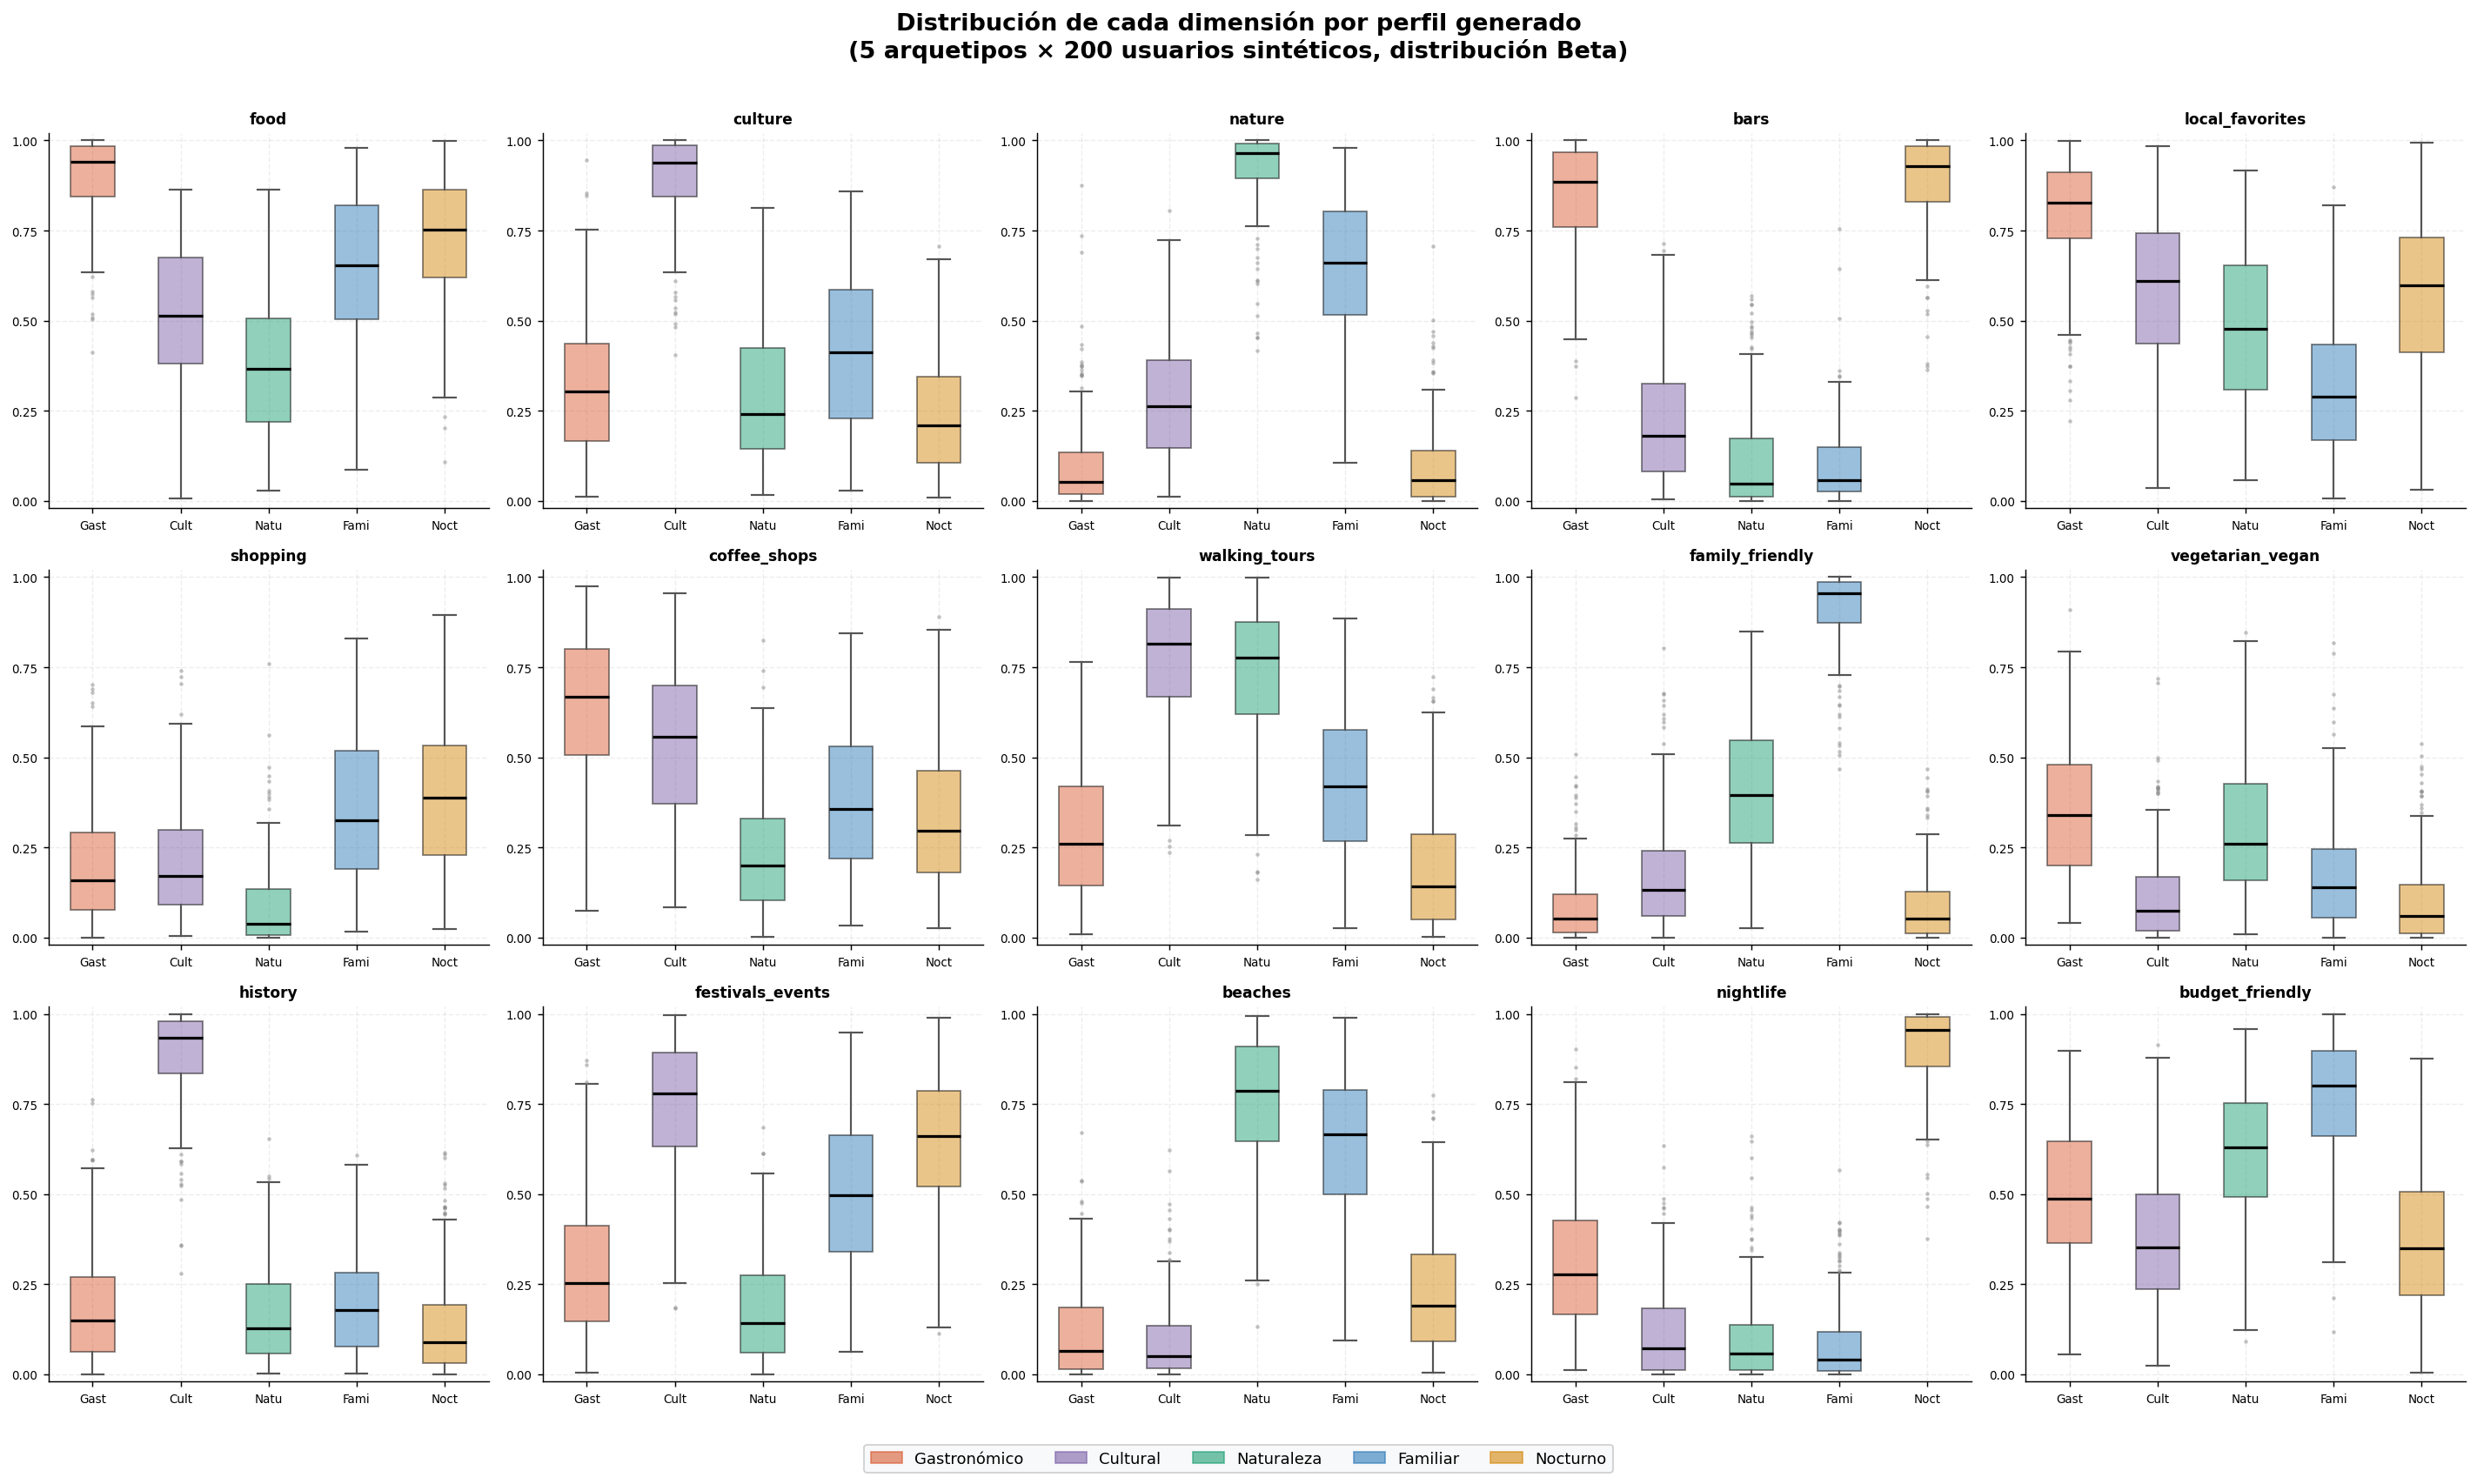

In [6]:
import os
import matplotlib.patches as mpatches

os.makedirs('figuras_cl', exist_ok=True)

profile_order = ['gast','cult','natu','fami','noct']
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
fig.patch.set_facecolor('white')
fig.suptitle('Distribución de cada dimensión por perfil generado\n(5 arquetipos × 200 usuarios sintéticos, distribución Beta)',
             fontsize=15, fontweight='bold', y=0.99)

for idx, dim in enumerate(PREFS):
    ax = axes[idx//5][idx%5]
    data = [df_u[df_u['profile']==p][dim].values for p in profile_order]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=[PNAMES[p][:4] for p in profile_order],
                    medianprops={'color':'black','lw':1.8},
                    whiskerprops={'color':'#555','lw':1.2},
                    capprops={'color':'#555','lw':1.2},
                    flierprops={'marker':'o','markersize':2.5,'markerfacecolor':'#888',
                                'markeredgecolor':'none','alpha':0.5})
    for patch, prof in zip(bp['boxes'], profile_order):
        patch.set_facecolor(PCOLS[prof]); patch.set_alpha(0.48)
    ax.set_title(dim, fontsize=9.5, fontweight='600')
    ax.set_ylim([-0.02,1.02]); ax.set_facecolor('white')
    ax.tick_params(labelsize=7.5); ax.set_yticks([0,0.25,0.5,0.75,1.0])

legend_patches = [mpatches.Patch(color=PCOLS[p],alpha=0.6,label=PNAMES[p]) for p in profile_order]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5,-0.01), framealpha=0.9)
plt.tight_layout(rect=[0,0.03,1,0.98])
plt.savefig('figuras_cl/fc01_boxplots_perfiles.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()

## 4. Método del codo + Silhouette ★ + Davies-Bouldin

Evaluamos K de 2 a 10 con tres criterios. Los tres apuntan a **K=3**.

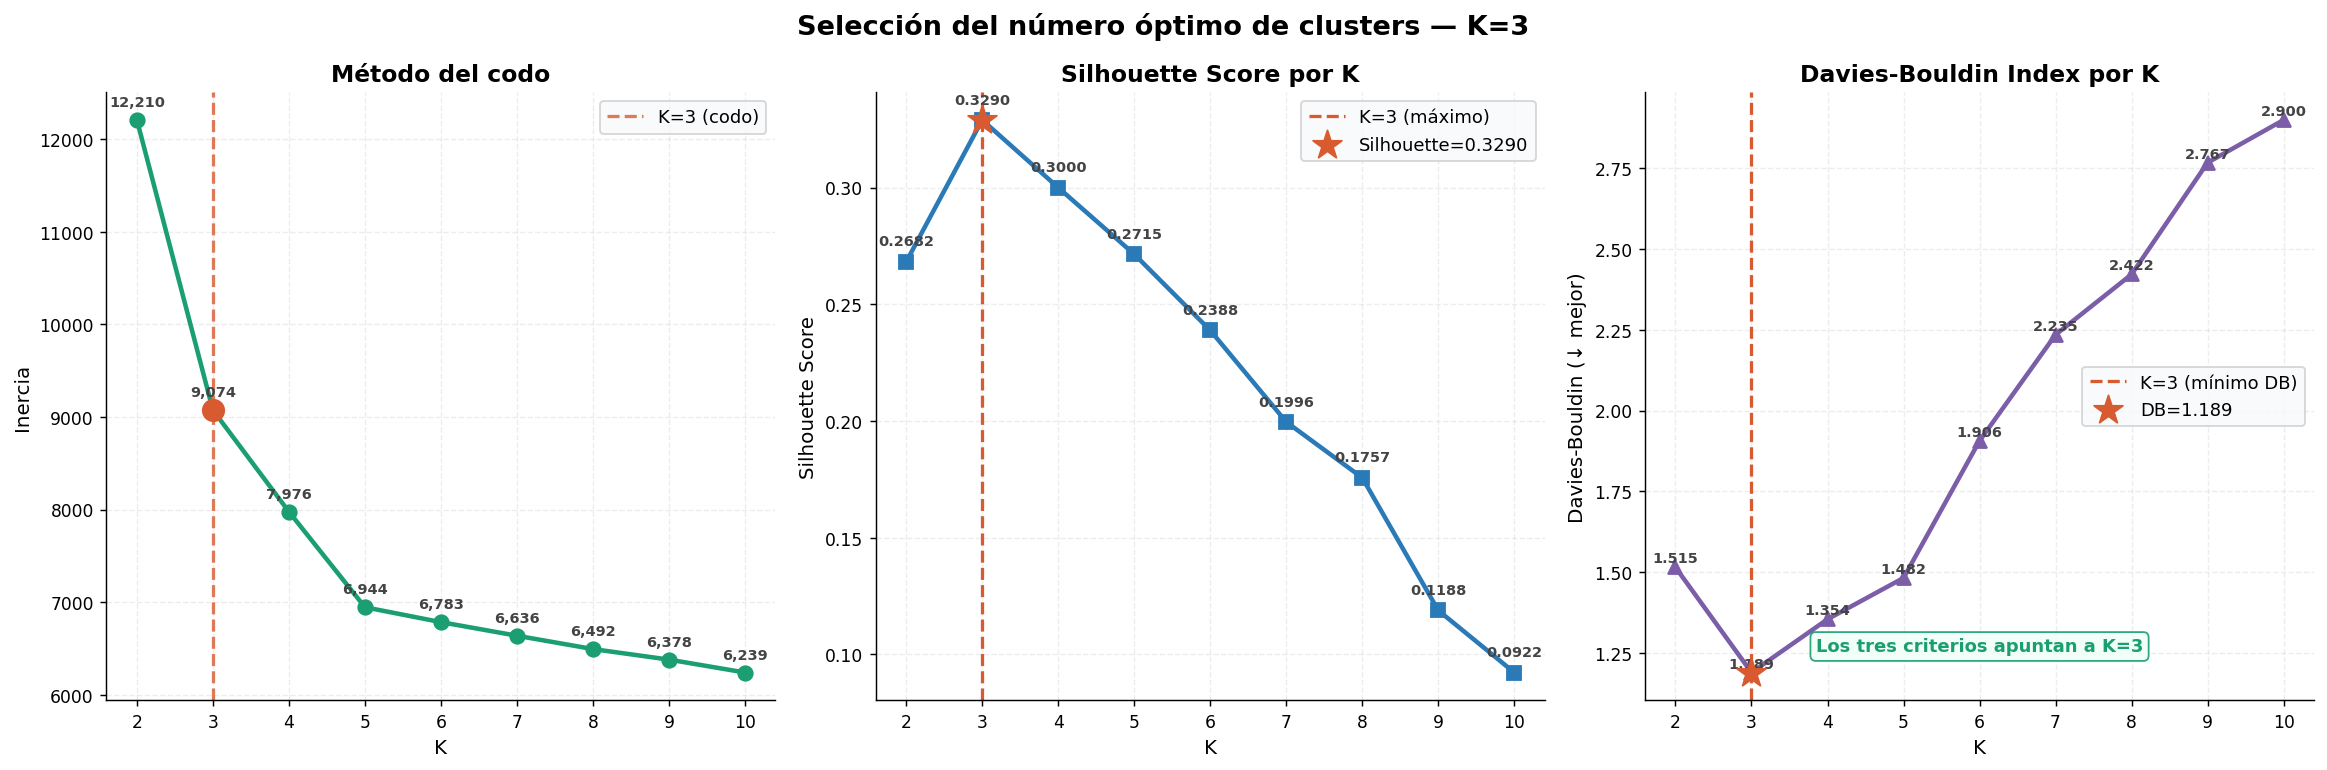

Silhouette por K:
  K=2: 0.2682
  K=3: 0.3290 ← ÓPTIMO ★
  K=4: 0.3000
  K=5: 0.2715
  K=6: 0.2388
  K=7: 0.1996
  K=8: 0.1757
  K=9: 0.1188
  K=10: 0.0922


In [7]:
X_cl = df_u[DIMS].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_cl)

K_RANGE = range(2,11)
inertias, silhouettes, db_scores = [], [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbs = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, lbs))
    db_scores.append(davies_bouldin_score(X_sc, lbs))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Selección del número óptimo de clusters — K=3', fontsize=15, fontweight='bold')

k_list = list(K_RANGE)
k_opt  = k_list[silhouettes.index(max(silhouettes))]

# Codo
axes[0].plot(k_list, inertias, 'o-', color=C['verde'], lw=2.5, markersize=8)
for k,ine in zip(k_list,inertias):
    axes[0].text(k, ine+150, f'{int(ine):,}', ha='center', fontsize=8, fontweight='600', color='#444')
axes[0].axvline(3, color=C['txoko'], ls='--', lw=1.8, label='K=3 (codo)', alpha=0.8)
axes[0].scatter([3],[inertias[1]], s=140, color=C['txoko'], zorder=6)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].set_facecolor('white')

# Silhouette con ESTRELLA
axes[1].plot(k_list, silhouettes, 's-', color=C['azul'], lw=2.5, markersize=8)
for k,s in zip(k_list, silhouettes):
    axes[1].text(k, s+0.007, f'{s:.4f}', ha='center', fontsize=8, fontweight='600', color='#444')
axes[1].axvline(k_opt, color=C['txoko'], ls='--', lw=1.8, label=f'K={k_opt} (máximo)')
axes[1].scatter([k_opt],[silhouettes[k_list.index(k_opt)]], s=280, color=C['txoko'], zorder=7,
                marker='*', label=f'Silhouette={silhouettes[k_list.index(k_opt)]:.4f}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].set_facecolor('white')

# Davies-Bouldin
db_opt = k_list[db_scores.index(min(db_scores))]
axes[2].plot(k_list, db_scores, '^-', color=C['morado'], lw=2.5, markersize=8)
for k,d in zip(k_list,db_scores):
    axes[2].text(k, d+0.015, f'{d:.3f}', ha='center', fontsize=8, fontweight='600', color='#444')
axes[2].axvline(db_opt, color=C['txoko'], ls='--', lw=1.8, label=f'K={db_opt} (mínimo DB)')
axes[2].scatter([db_opt],[min(db_scores)], s=280, color=C['txoko'], zorder=7, marker='*',
                label=f'DB={min(db_scores):.3f}')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Davies-Bouldin (↓ mejor)')
axes[2].set_title('Davies-Bouldin Index por K', fontweight='bold')
axes[2].legend(fontsize=10); axes[2].set_facecolor('white')
axes[2].text(0.5, 0.08, 'Los tres criterios apuntan a K=3',
             transform=axes[2].transAxes, ha='center', fontsize=10, fontweight='600', color=C['verde'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FFF8', edgecolor=C['verde'], alpha=0.9))

plt.tight_layout()
plt.savefig('figuras_cl/fc02_seleccion_k.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()
print('Silhouette por K:')
for k,s in zip(k_list,silhouettes):
    mark = ' ← ÓPTIMO ★' if k==k_opt else ''
    print(f'  K={k}: {s:.4f}{mark}')

## 5. Modelo final K=3 — centroides y top 5 dimensiones

K=3  silhouette=0.3290  davies_bouldin=1.1892

Distribución:
cluster_name
Txoko Social       400
Mendi & Familia    400
Kultura            200


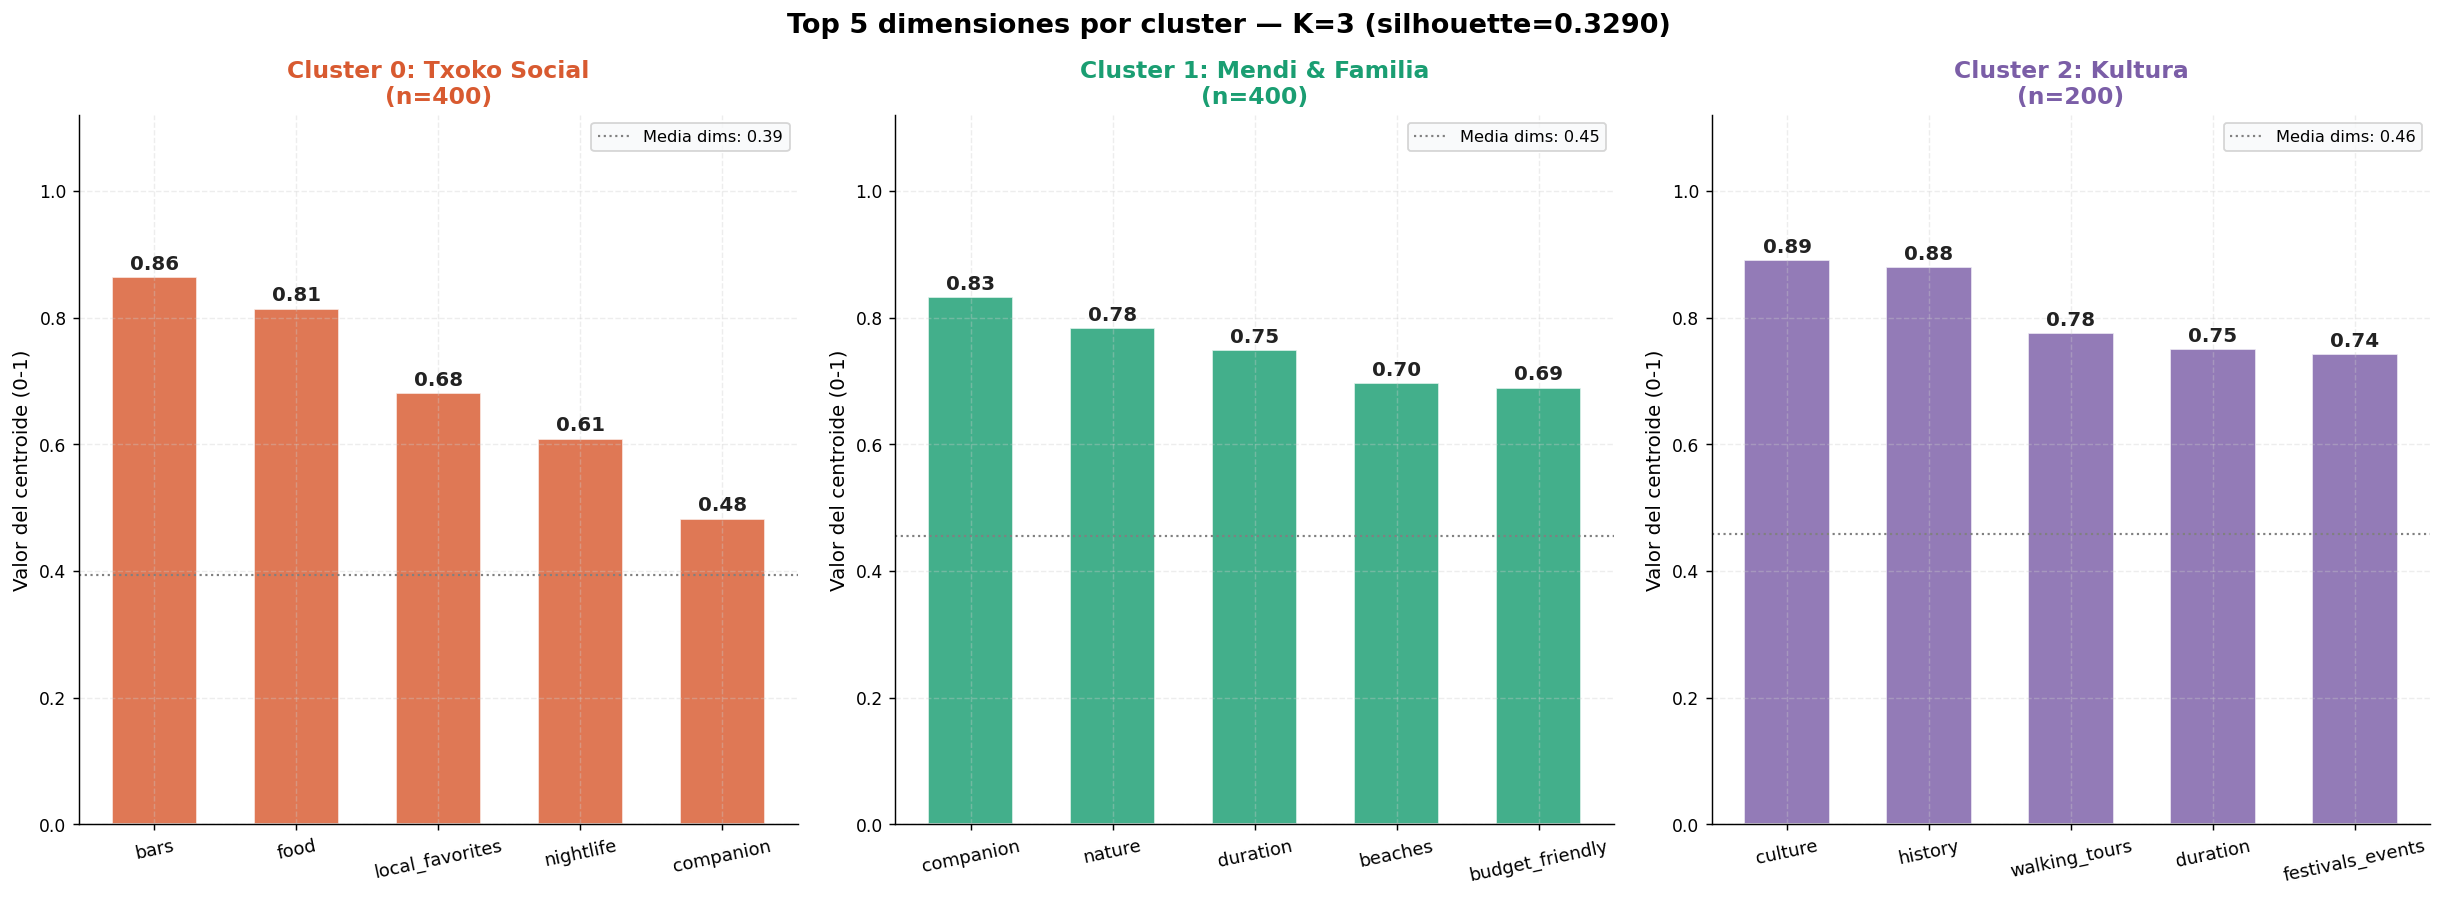

In [8]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=30)
labels3 = km3.fit_predict(X_sc)
sil3 = silhouette_score(X_sc, labels3)
db3  = davies_bouldin_score(X_sc, labels3)
centroids = scaler.inverse_transform(km3.cluster_centers_)
cd = pd.DataFrame(centroids, columns=DIMS)

def nombre_cluster(i):
    top = cd.iloc[i].nlargest(4).index.tolist()
    if any(d in top for d in ['bars','nightlife','food','local_favorites']): return 'Txoko Social'
    elif any(d in top for d in ['culture','history','walking_tours']): return 'Kultura'
    return 'Mendi & Familia'

CNAMES = {i:nombre_cluster(i) for i in range(3)}
taken=set()
for i in range(3):
    if CNAMES[i] in taken:
        for n in ['Txoko Social','Mendi & Familia','Kultura']:
            if n not in taken: CNAMES[i]=n; break
    taken.add(CNAMES[i])

df_u['cluster_name'] = [CNAMES[l] for l in labels3]
print(f'K=3  silhouette={sil3:.4f}  davies_bouldin={db3:.4f}')
print('\nDistribución:')
print(df_u['cluster_name'].value_counts().to_string())

cluster_order = ['Txoko Social','Mendi & Familia','Kultura']
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor('white')
fig.suptitle(f'Top 5 dimensiones por cluster — K=3 (silhouette={sil3:.4f})', fontsize=15, fontweight='bold')
for i,cname in enumerate(cluster_order):
    cid = [k for k,v in CNAMES.items() if v==cname][0]
    top5 = cd.iloc[cid].nlargest(5)
    n_u  = (df_u['cluster_name']==cname).sum()
    ax   = axes[i]; col = CCMAP[cname]
    bars = ax.bar(top5.index, top5.values, color=col, alpha=0.82, edgecolor='white', width=0.6)
    for bar,val in zip(bars, top5.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.012,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='700', color='#222')
    mean_all = cd.iloc[cid].mean()
    ax.axhline(mean_all, color='gray', ls=':', lw=1.2, label=f'Media dims: {mean_all:.2f}')
    ax.set_title(f'Cluster {i}: {cname}\n(n={n_u})', fontweight='bold', fontsize=13, color=col)
    ax.set_ylabel('Valor del centroide (0-1)'); ax.set_ylim([0,1.12])
    ax.set_facecolor('white'); ax.tick_params(axis='x', labelsize=10, rotation=12)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras_cl/fc03_top5_dims.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()

## 6. Radar charts — perfil de personalidad de los 3 clusters

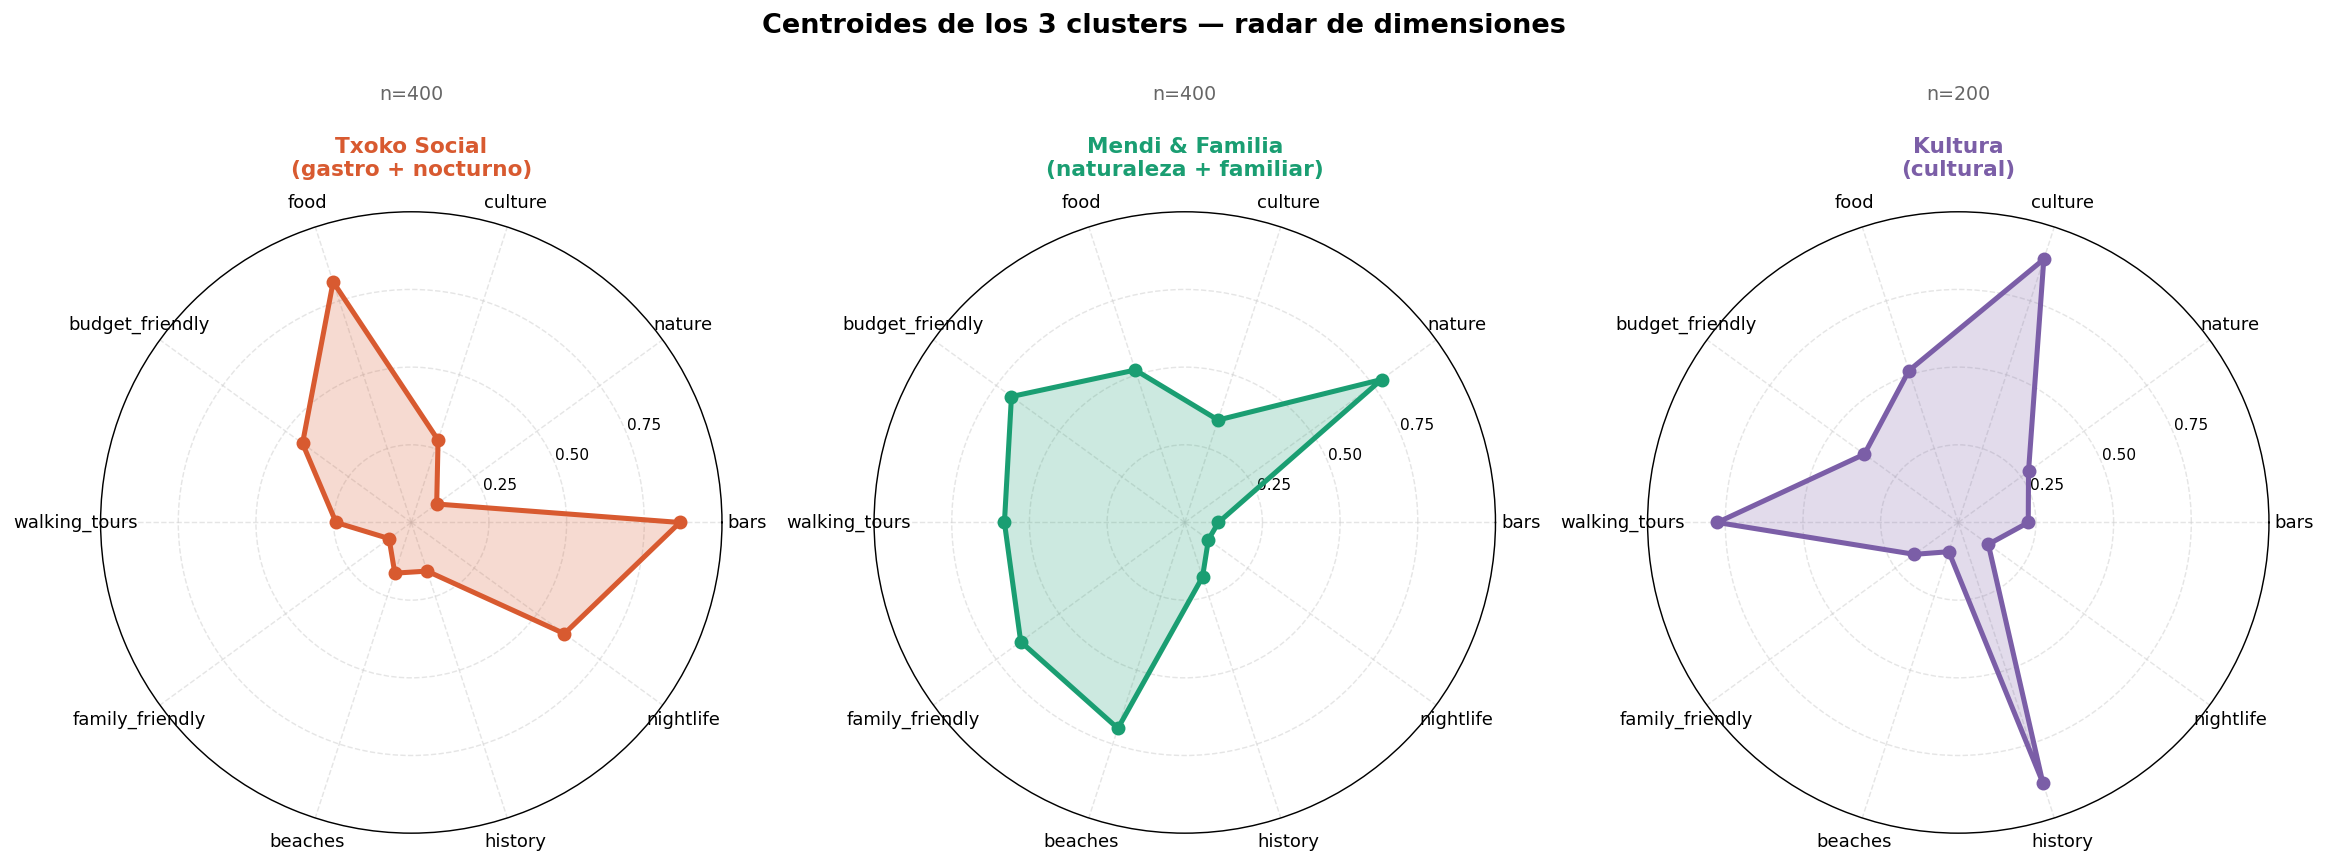

In [9]:
DIMS_R = ['bars','nature','culture','food','budget_friendly','walking_tours',
          'family_friendly','beaches','history','nightlife']
N_R = len(DIMS_R)
angles = np.linspace(0, 2*np.pi, N_R, endpoint=False).tolist() + [0]

CLUSTER_SUBTITLES = {'Txoko Social':'(gastro + nocturno)','Mendi & Familia':'(naturaleza + familiar)','Kultura':'(cultural)'}
fig, axes = plt.subplots(1, 3, figsize=(18, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')
fig.suptitle('Centroides de los 3 clusters — radar de dimensiones', fontsize=15, fontweight='bold', y=1.02)

for i,(cname,ax) in enumerate(zip(cluster_order,axes)):
    cid = [k for k,v in CNAMES.items() if v==cname][0]
    vals = cd.iloc[cid][DIMS_R].values.tolist() + [cd.iloc[cid][DIMS_R[0]]]
    col  = CCMAP[cname]
    n_u  = (df_u['cluster_name']==cname).sum()
    ax.plot(angles, vals, color=col, lw=2.8, zorder=4)
    ax.fill(angles, vals, color=col, alpha=0.22, zorder=3)
    ax.scatter(angles[:-1], vals[:-1], s=45, color=col, zorder=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(DIMS_R, size=10)
    ax.set_ylim(0,1); ax.set_yticks([0.25,0.50,0.75])
    ax.set_yticklabels(['0.25','0.50','0.75'], size=8.5)
    ax.set_title(f'{cname}\n{CLUSTER_SUBTITLES[cname]}', fontweight='bold', pad=20, color=col, fontsize=12)
    ax.text(0.5,1.18,f'n={n_u}', transform=ax.transAxes, ha='center', fontsize=10.5, color='#666')
    ax.set_facecolor('white'); ax.grid(color='#CCCCCC', alpha=0.5)

plt.tight_layout()
plt.savefig('figuras_cl/fc04_radar.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()

## 7. Análisis de silhouette por muestra

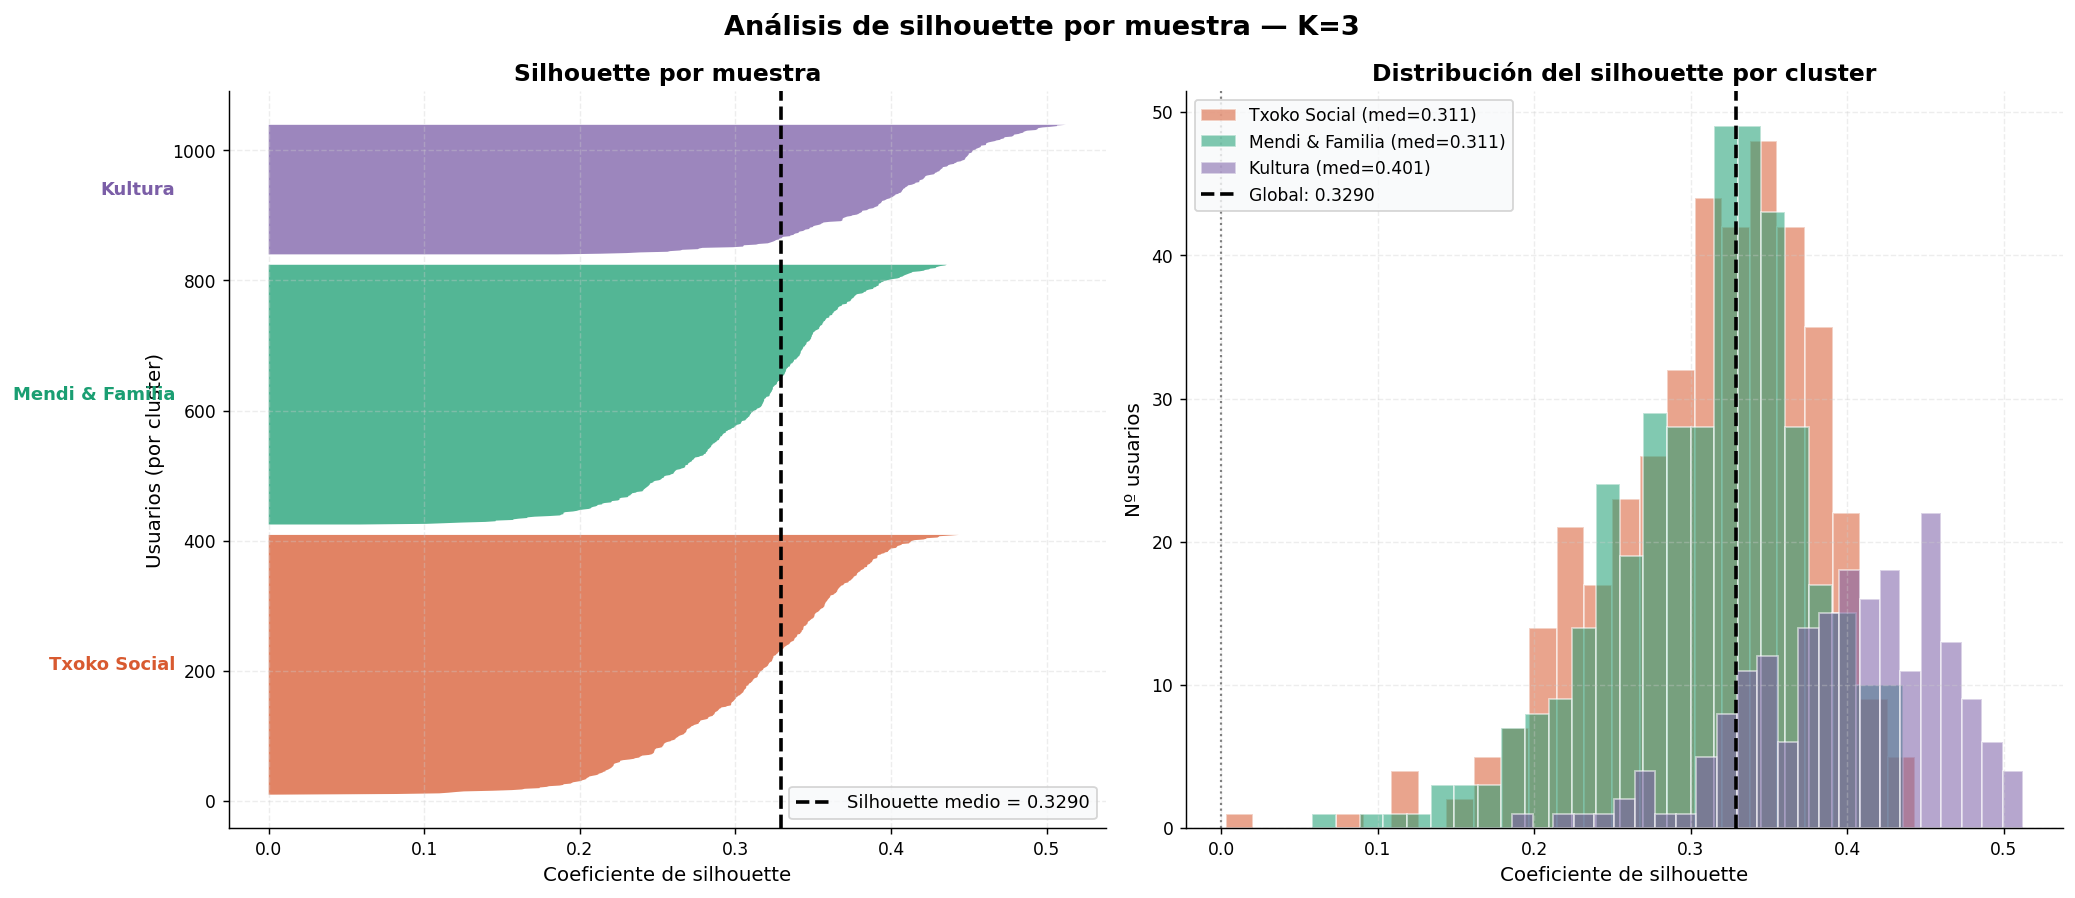

Silhouette global: 0.3290
  Txoko Social: media=0.3114  % > 0.3: 63.2%
  Mendi & Familia: media=0.3107  % > 0.3: 62.0%
  Kultura: media=0.4007  % > 0.3: 94.0%


In [10]:
sil_vals = silhouette_samples(X_sc, labels3)
df_u['sil_score'] = sil_vals

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Análisis de silhouette por muestra — K=3', fontsize=15, fontweight='bold')

# Silhouette plot clásico
ax = axes[0]; y_lower = 10
for cname in cluster_order:
    cid = [k for k,v in CNAMES.items() if v==cname][0]
    mask = labels3 == cid
    ith = np.sort(sil_vals[mask])
    size = ith.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower,y_upper), 0, ith, facecolor=CCMAP[cname], alpha=0.75)
    ax.text(-0.06, y_lower+size/2, cname, ha='right', va='center',
            fontsize=10, fontweight='600', color=CCMAP[cname])
    y_lower = y_upper + 15
ax.axvline(sil3, color='black', ls='--', lw=2, label=f'Silhouette medio = {sil3:.4f}')
ax.set_xlabel('Coeficiente de silhouette'); ax.set_ylabel('Usuarios (por cluster)')
ax.set_title('Silhouette por muestra', fontweight='bold'); ax.legend(fontsize=10)
ax.set_facecolor('white')

# Histograma por cluster
ax2 = axes[1]
for cname in cluster_order:
    cid = [k for k,v in CNAMES.items() if v==cname][0]
    mask = labels3==cid
    ax2.hist(sil_vals[mask], bins=25, color=CCMAP[cname], alpha=0.55,
             edgecolor='white', label=f'{cname} (med={sil_vals[mask].mean():.3f})')
ax2.axvline(sil3, color='black', ls='--', lw=2, label=f'Global: {sil3:.4f}')
ax2.axvline(0, color='gray', ls=':', lw=1.2)
ax2.set_xlabel('Coeficiente de silhouette'); ax2.set_ylabel('Nº usuarios')
ax2.set_title('Distribución del silhouette por cluster', fontweight='bold')
ax2.legend(fontsize=9.5); ax2.set_facecolor('white')

plt.tight_layout()
plt.savefig('figuras_cl/fc05_silhouette.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()
print(f'Silhouette global: {sil3:.4f}')
for cname in cluster_order:
    cid=[k for k,v in CNAMES.items() if v==cname][0]
    vals=sil_vals[labels3==cid]
    print(f'  {cname}: media={vals.mean():.4f}  % > 0.3: {(vals>0.3).mean()*100:.1f}%')

## 8. PCA 2D — visualización de clusters y colapso de arquetipos

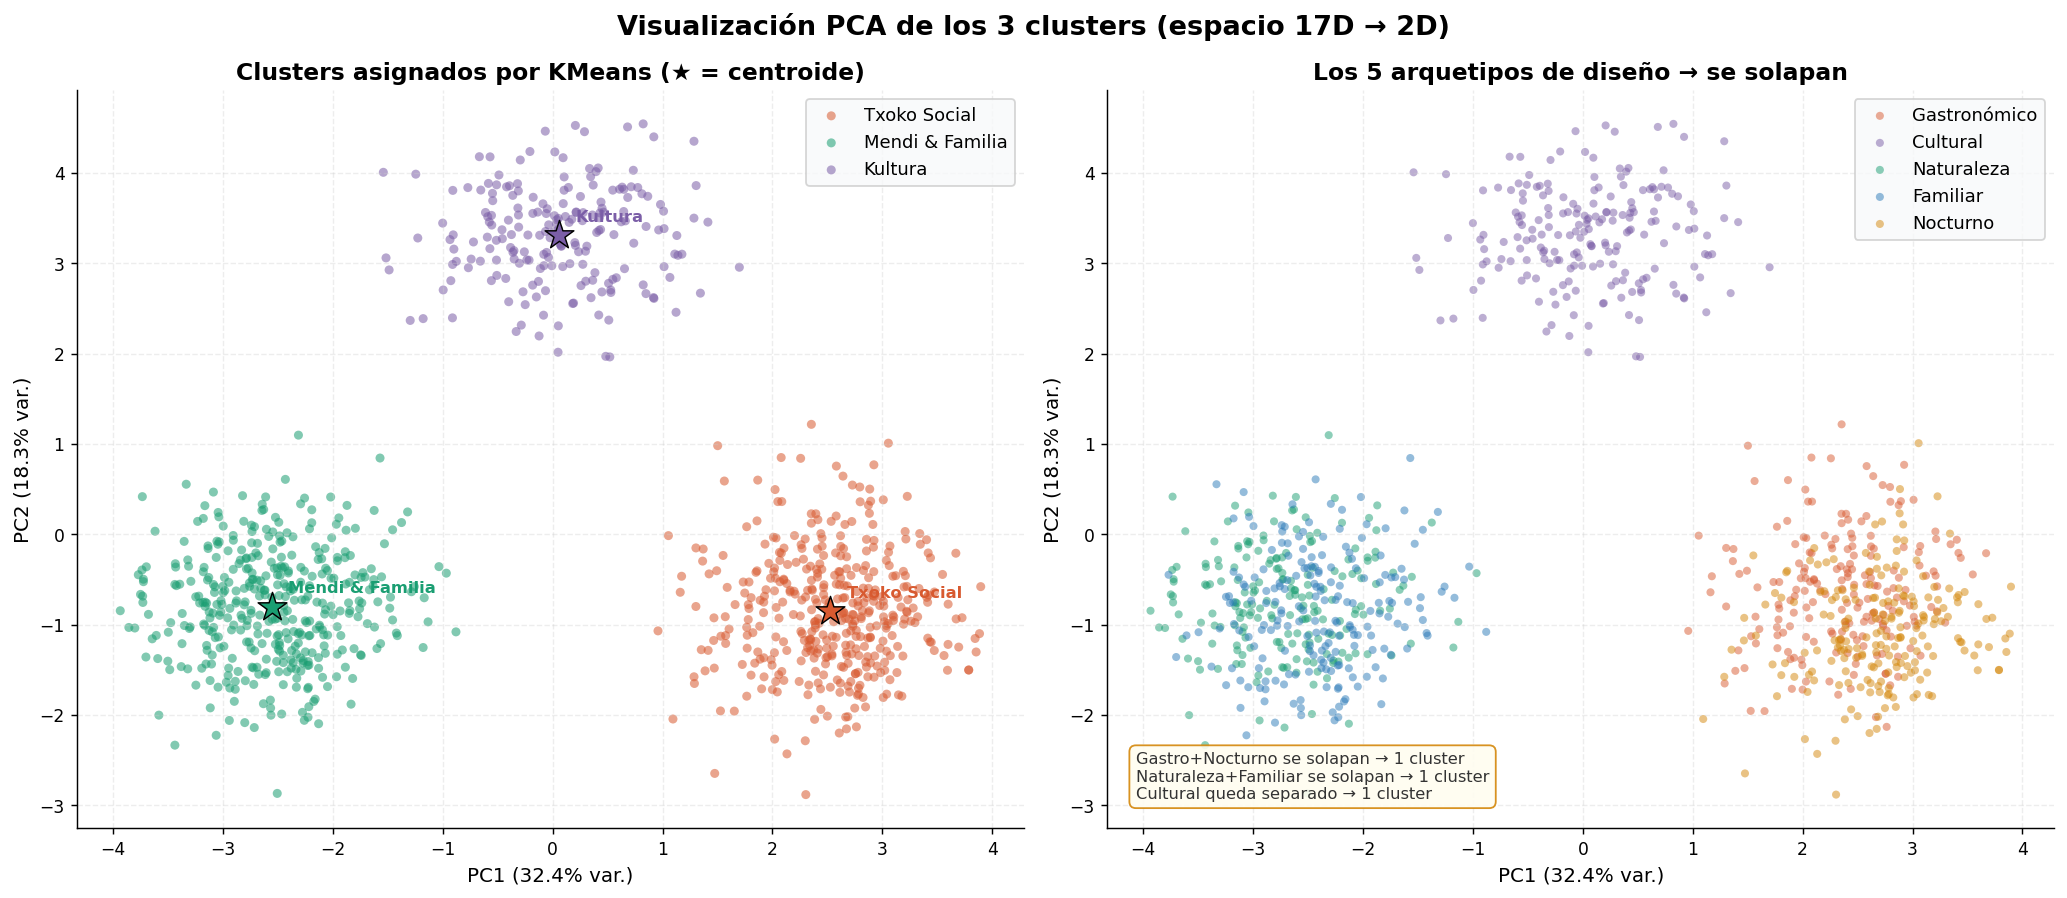

Varianza explicada: PC1=32.4%  PC2=18.3%  Total=50.7%


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
varexp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Visualización PCA de los 3 clusters (espacio 17D → 2D)', fontsize=15, fontweight='bold')

for cname in cluster_order:
    cid=[k for k,v in CNAMES.items() if v==cname][0]
    mask=labels3==cid
    axes[0].scatter(X_pca[mask,0],X_pca[mask,1],c=CCMAP[cname],s=25,alpha=0.55,label=cname,edgecolors='none')
centroids_pca = pca.transform(km3.cluster_centers_)
for i,cname in enumerate(CNAMES.values()):
    axes[0].scatter(*centroids_pca[i],s=280,color=CCMAP[cname],marker='*',zorder=10,edgecolors='black',linewidths=0.8)
    axes[0].annotate(cname,centroids_pca[i],fontsize=9,fontweight='700',color=CCMAP[cname],
                     xytext=(centroids_pca[i,0]+0.15,centroids_pca[i,1]+0.15))
axes[0].set_xlabel(f'PC1 ({varexp[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({varexp[1]*100:.1f}% var.)')
axes[0].set_title('Clusters asignados por KMeans (★ = centroide)', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].set_facecolor('white')

for pname,plong in [('gast','Gastronómico'),('cult','Cultural'),('natu','Naturaleza'),('fami','Familiar'),('noct','Nocturno')]:
    mask=df_u['profile'].values==pname
    axes[1].scatter(X_pca[mask,0],X_pca[mask,1],c=({'gast':C['txoko'],'cult':C['morado'],'natu':C['verde'],'fami':C['azul'],'noct':C['naranja']}[pname]),
                    s=20,alpha=0.50,label=plong,edgecolors='none')
axes[1].set_xlabel(f'PC1 ({varexp[0]*100:.1f}% var.)')
axes[1].set_ylabel(f'PC2 ({varexp[1]*100:.1f}% var.)')
axes[1].set_title('Los 5 arquetipos de diseño → se solapan', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].set_facecolor('white')
axes[1].text(0.03,0.04,
    'Gastro+Nocturno se solapan → 1 cluster\nNaturaleza+Familiar se solapan → 1 cluster\nCultural queda separado → 1 cluster',
    transform=axes[1].transAxes,fontsize=9,color='#333',
    bbox=dict(boxstyle='round,pad=0.4',facecolor='#FFFDF0',edgecolor=C['naranja'],alpha=0.9))

plt.tight_layout()
plt.savefig('figuras_cl/fc06_pca.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()
print(f'Varianza explicada: PC1={varexp[0]*100:.1f}%  PC2={varexp[1]*100:.1f}%  Total={sum(varexp)*100:.1f}%')

## 9. Heatmap completo de centroides (17 dimensiones)

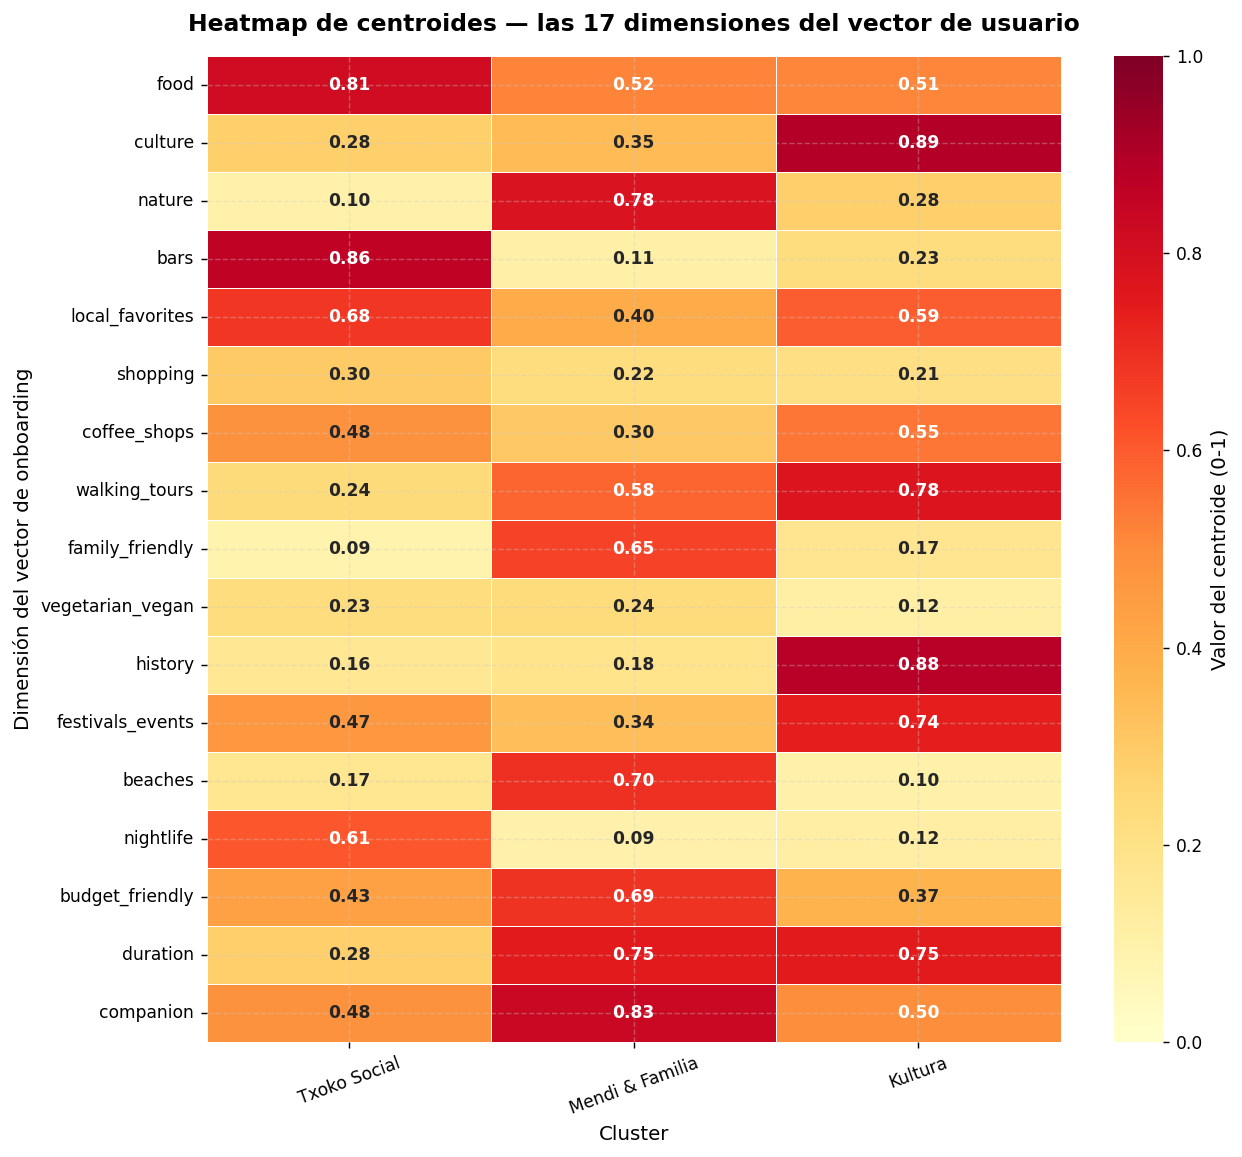

In [12]:
centroid_df = pd.DataFrame(
    {CNAMES[i]:cd.iloc[i][DIMS].values for i in range(3)},
    index=DIMS
)
fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('white')
sns.heatmap(centroid_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, annot_kws={'size':9.5,'weight':'600'},
            vmin=0, vmax=1, cbar_kws={'label':'Valor del centroide (0-1)'})
ax.set_title('Heatmap de centroides — las 17 dimensiones del vector de usuario',
             fontweight='bold', fontsize=13, pad=14)
ax.set_xlabel('Cluster'); ax.set_ylabel('Dimensión del vector de onboarding')
ax.tick_params(axis='x', rotation=20); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('figuras_cl/fc07_heatmap.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()

## 10. Composición de clusters y hallazgo clave 5→3

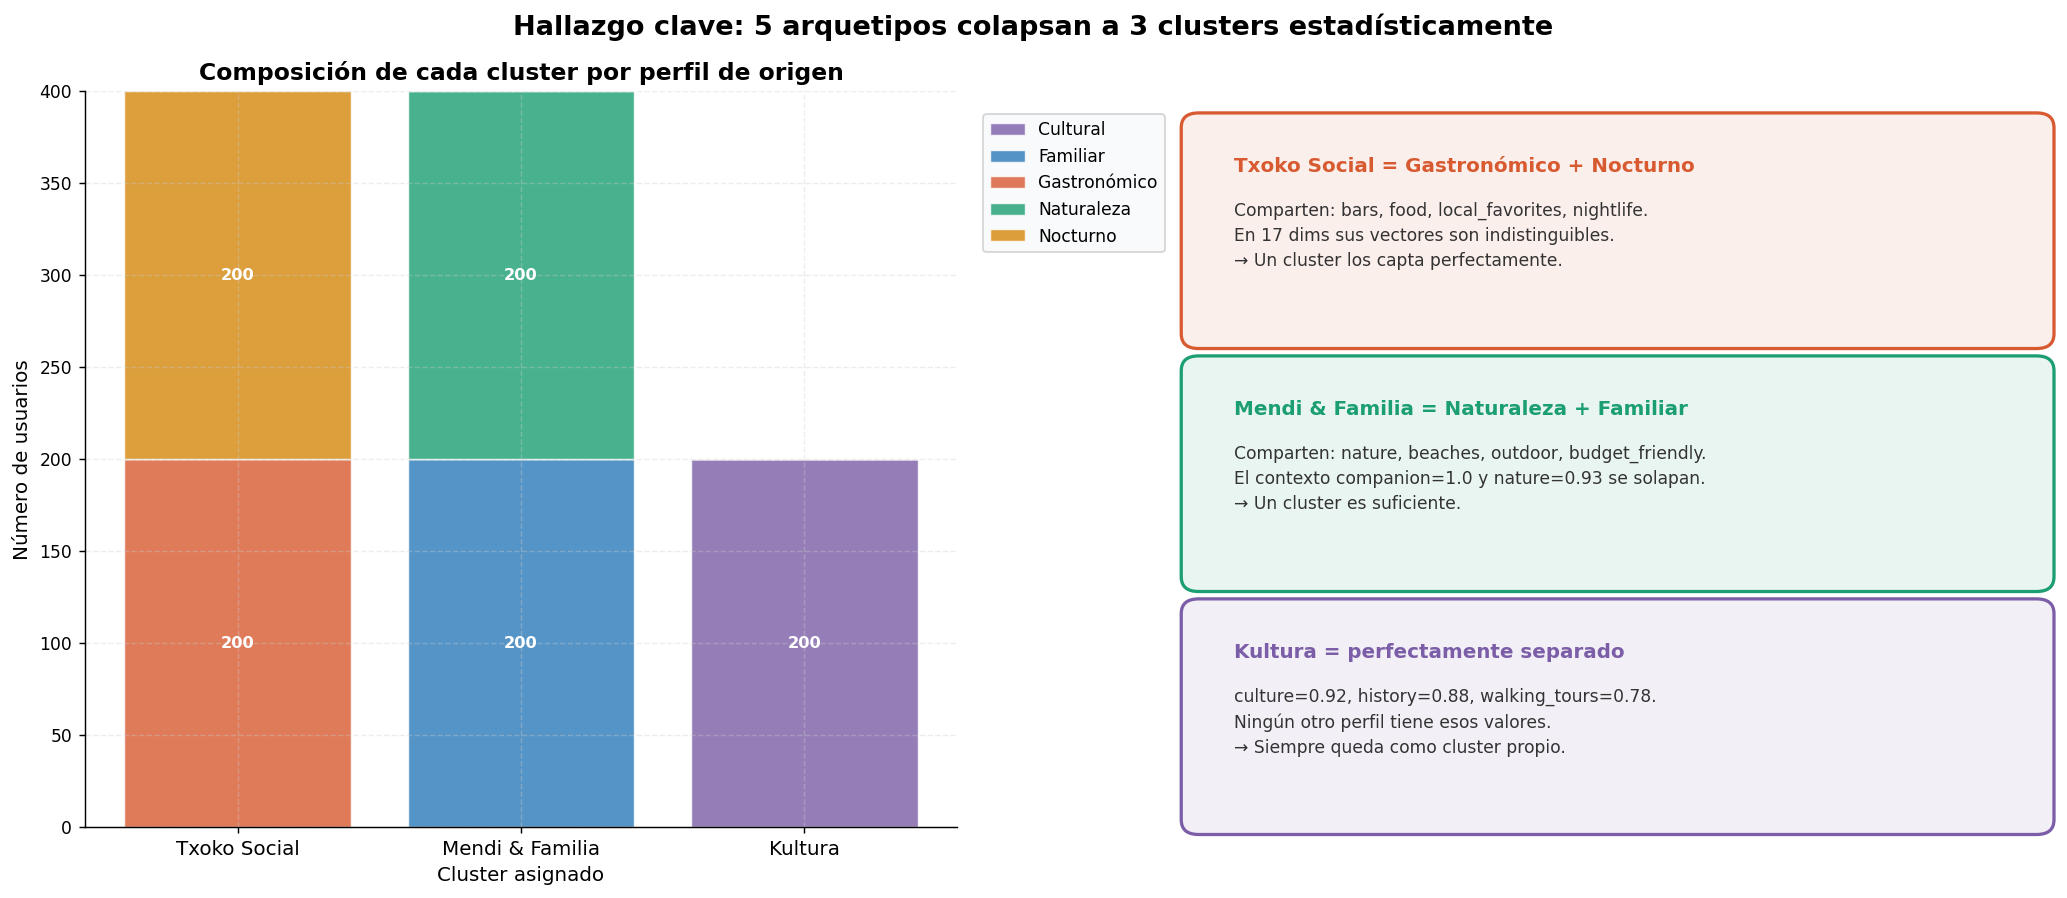

Composición de clusters:
profile_name     Cultural  Familiar  Gastronómico  Naturaleza  Nocturno
cluster_name                                                           
Txoko Social            0         0           200           0       200
Mendi & Familia         0       200             0         200         0
Kultura               200         0             0           0         0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Hallazgo clave: 5 arquetipos colapsan a 3 clusters estadísticamente', fontsize=15, fontweight='bold')

ct = pd.crosstab(df_u['cluster_name'], df_u['profile_name'])
ct = ct.reindex(cluster_order)
bottom = np.zeros(len(ct))
PCOLS2 = {'Gastronómico':C['txoko'],'Cultural':C['morado'],'Naturaleza':C['verde'],'Familiar':C['azul'],'Nocturno':C['naranja']}
for pname in ct.columns:
    vals = ct[pname].values
    bars = axes[0].bar(range(len(ct)), vals, bottom=bottom, color=PCOLS2.get(pname,'gray'), label=pname,
                       alpha=0.80, edgecolor='white', linewidth=0.8)
    for i,(bar,v) in enumerate(zip(bars,vals)):
        if v>15:
            axes[0].text(bar.get_x()+bar.get_width()/2, bottom[i]+v/2,
                         str(v), ha='center', va='center', fontsize=9, fontweight='600', color='white')
    bottom += vals
axes[0].set_xticks(range(len(ct))); axes[0].set_xticklabels(ct.index, fontsize=11)
axes[0].set_ylabel('Número de usuarios'); axes[0].set_xlabel('Cluster asignado')
axes[0].set_title('Composición de cada cluster por perfil de origen', fontweight='bold')
axes[0].legend(fontsize=9.5, bbox_to_anchor=(1.02,0.98), loc='upper left')
axes[0].set_facecolor('white')

axes[1].axis('off'); axes[1].set_facecolor('white')
hallazgos = [
    (C['txoko'], 'Txoko Social = Gastronómico + Nocturno',
     'Comparten: bars, food, local_favorites, nightlife.\nEn 17 dims sus vectores son indistinguibles.\n→ Un cluster los capta perfectamente.'),
    (C['verde'], 'Mendi & Familia = Naturaleza + Familiar',
     'Comparten: nature, beaches, outdoor, budget_friendly.\nEl contexto companion=1.0 y nature=0.93 se solapan.\n→ Un cluster es suficiente.'),
    (C['morado'], 'Kultura = perfectamente separado',
     'culture=0.92, history=0.88, walking_tours=0.78.\nNingún otro perfil tiene esos valores.\n→ Siempre queda como cluster propio.'),
]
for i,(col,title,desc) in enumerate(hallazgos):
    y_top = 0.95-i*0.33
    rect = mpatches.FancyBboxPatch((0.02,y_top-0.28),0.96,0.28,
        boxstyle='round,pad=0.02', linewidth=1.8, edgecolor=col,
        facecolor=col+'18', transform=axes[1].transAxes, clip_on=False)
    axes[1].add_patch(rect)
    axes[1].text(0.06,y_top-0.04,title,transform=axes[1].transAxes,
                 fontsize=11,fontweight='bold',color=col,va='top')
    axes[1].text(0.06,y_top-0.10,desc,transform=axes[1].transAxes,
                 fontsize=9.5,va='top',color='#333',linespacing=1.5)

plt.tight_layout()
plt.savefig('figuras_cl/fc08_composicion.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()
print('Composición de clusters:')
print(ct.to_string())

## 11. Boxplots de dimensiones clave por cluster asignado

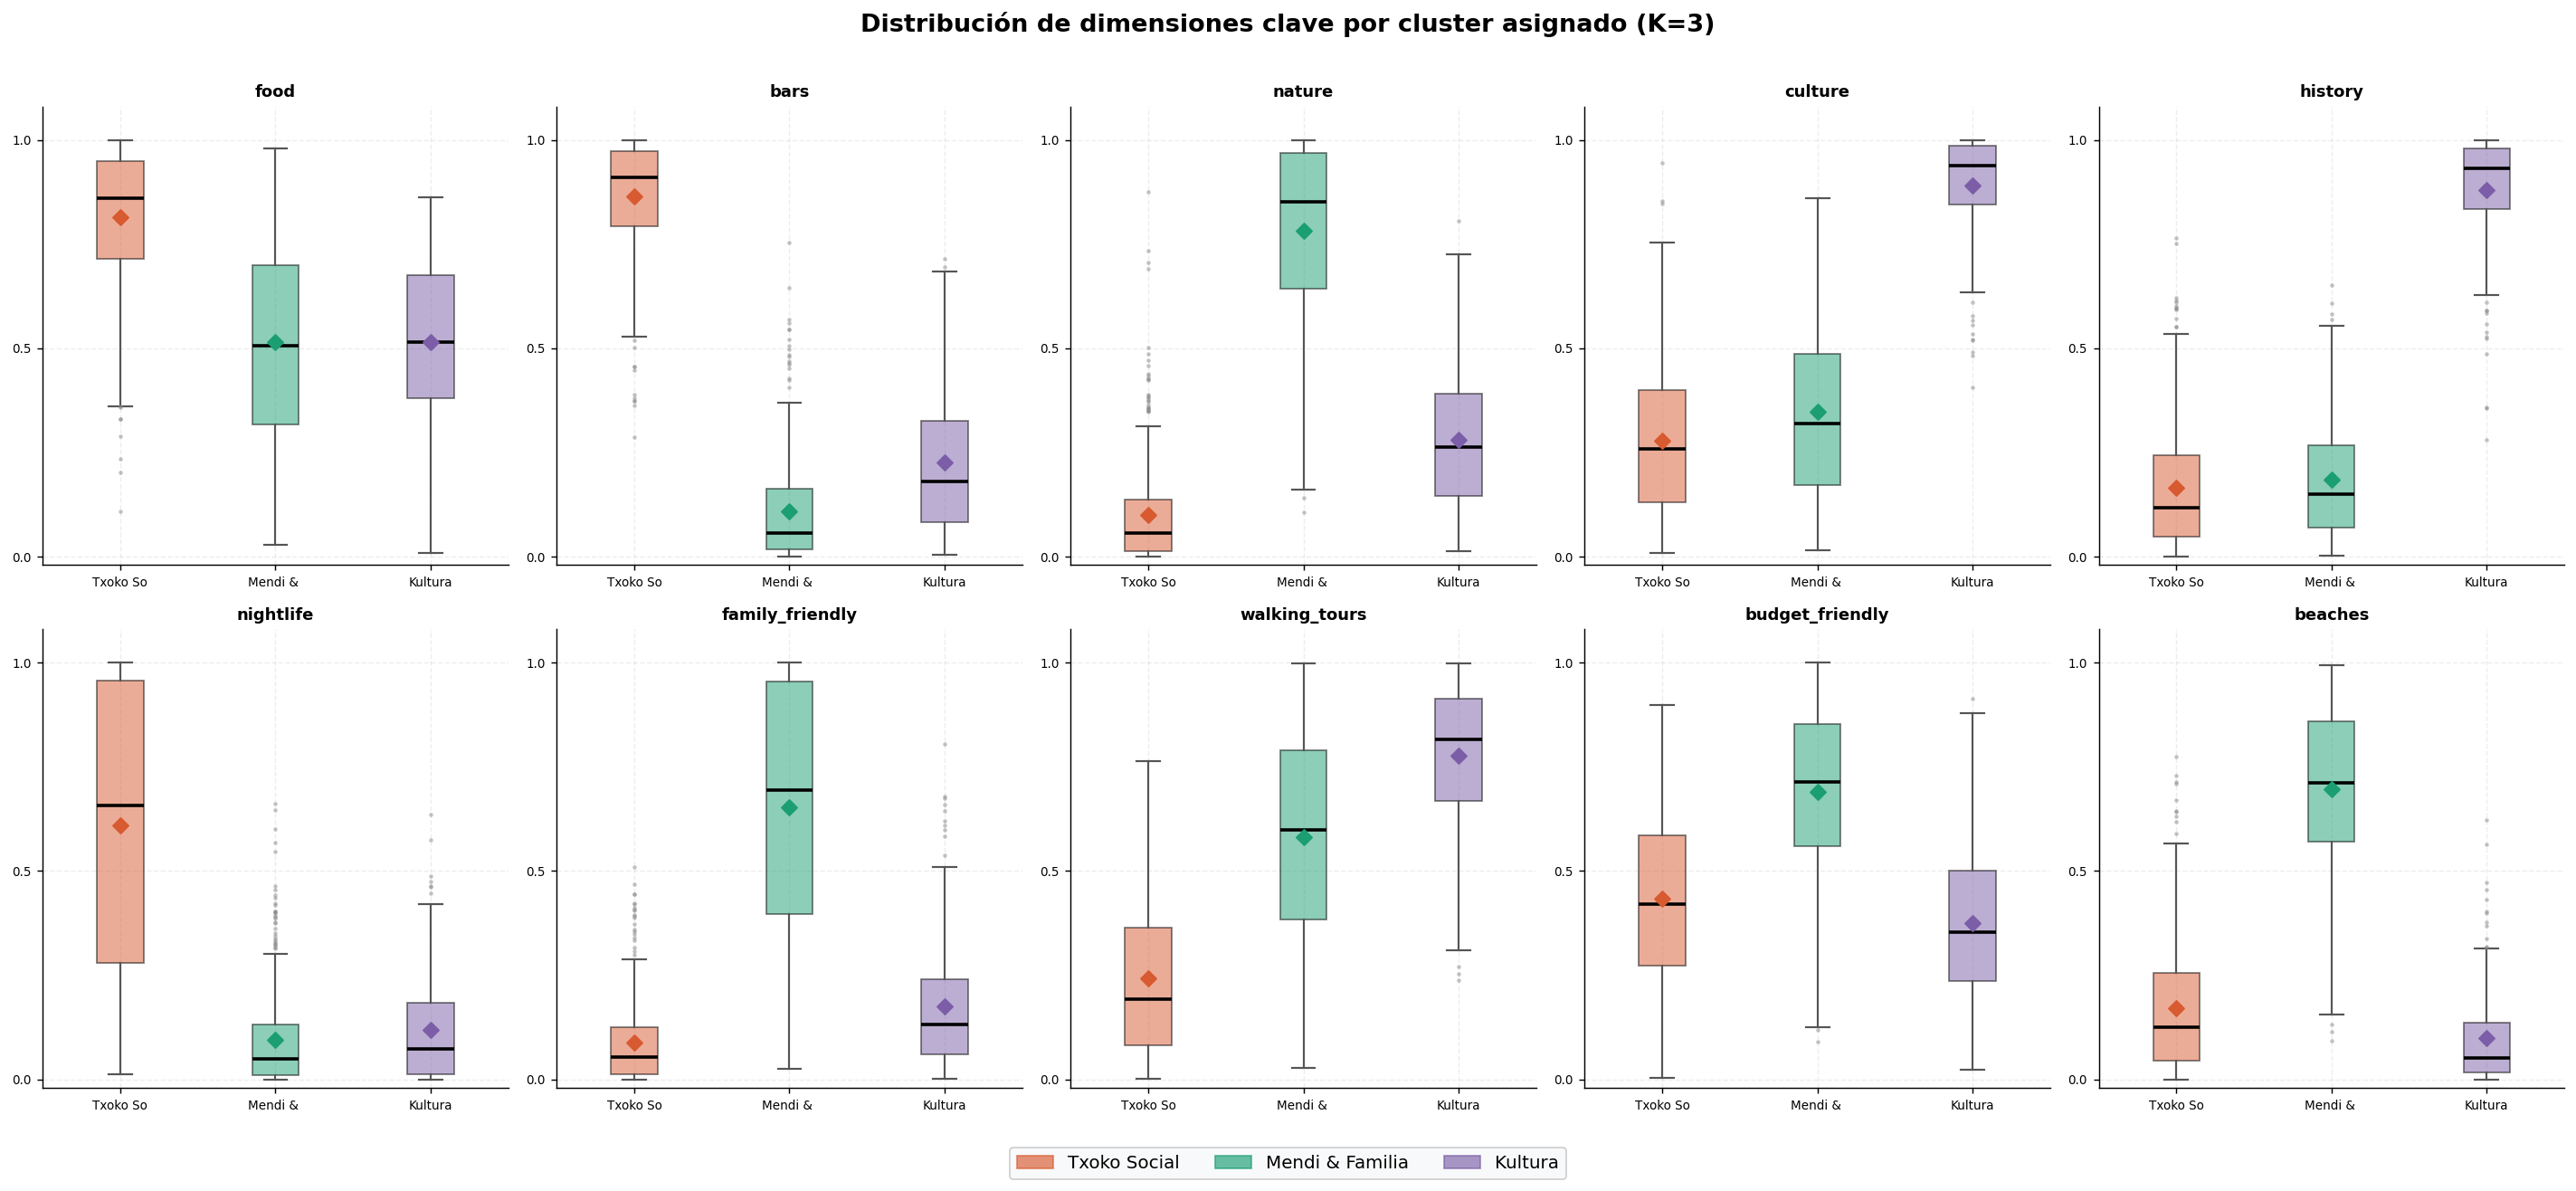

In [14]:
KEY_DIMS = ['food','bars','nature','culture','history','nightlife',
            'family_friendly','walking_tours','budget_friendly','beaches']
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.patch.set_facecolor('white')
fig.suptitle('Distribución de dimensiones clave por cluster asignado (K=3)', fontsize=15, fontweight='bold', y=0.99)

for idx,dim in enumerate(KEY_DIMS):
    ax = axes[idx//5][idx%5]
    data = [df_u[df_u['cluster_name']==cn][dim].values for cn in cluster_order]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=[cn[:8] for cn in cluster_order],
                    medianprops={'color':'black','lw':2},
                    whiskerprops={'color':'#555','lw':1.2},
                    capprops={'color':'#555','lw':1.2},
                    flierprops={'marker':'o','markersize':2.5,'markerfacecolor':'#888','markeredgecolor':'none','alpha':0.5})
    for patch,cname in zip(bp['boxes'],cluster_order):
        patch.set_facecolor(CCMAP[cname]); patch.set_alpha(0.50)
    for i,cname in enumerate(cluster_order):
        mean_v = df_u[df_u['cluster_name']==cname][dim].mean()
        ax.scatter([i+1],[mean_v],s=45,color=CCMAP[cname],zorder=5,marker='D')
    ax.set_title(dim, fontsize=10, fontweight='600')
    ax.set_ylim([-0.02,1.08]); ax.set_facecolor('white')
    ax.tick_params(labelsize=7.5); ax.set_yticks([0,0.5,1.0])

legend_patches = [mpatches.Patch(color=CCMAP[cn],alpha=0.65,label=cn) for cn in cluster_order]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5,-0.01), framealpha=0.9)
plt.tight_layout(rect=[0,0.04,1,0.98])
plt.savefig('figuras_cl/fc09_boxplots_clusters.png', bbox_inches='tight', dpi=130, facecolor='white')
plt.show()

## 13 Función de predicción para producción

Esta función recibe exactamente lo que el usuario introduce en el onboarding y devuelve el cluster asignado. Es la interfaz que usará el endpoint `/recommend` de la API.

**Nota sobre la conversión del vector de producción:**
El usuario real da 3 preferencias binarias + 1 duración + 1 compañía. Antes de pasarlo al modelo, convertimos `duration` y `companion` a sus valores ordinales [0.25–1.0] usando los mismos mapeos que se usaron en la generación sintética. El `StandardScaler` hace el resto: transforma el vector al mismo espacio que aprendió durante el entrenamiento.


In [ ]:
def predecir_perfil(preferencias: list, duracion: str, compania: str) -> dict:
    """
    Asigna un usuario nuevo al cluster más cercano.

    Args:
        preferencias : lista con exactamente 3 strings de PREFS
                       ej: ['food', 'bars', 'local_favorites']
        duracion     : una de ['1_dia', '2_3_dias', '4_7_dias', 'mas_de_7']
        compania     : una de ['solo', 'pareja', 'amigos', 'familia']

    Returns:
        dict con cluster_id, perfil, subcategorias recomendadas y vibes
    """
    assert len(preferencias) == 3, "Deben ser exactamente 3 preferencias"
    assert all(p in PREFS for p in preferencias), f"Preferencia no válida: {preferencias}"
    assert duracion in DURATION_MAP,  f"Duración no válida: {duracion}"
    assert compania in COMPANION_MAP, f"Compañía no válida: {compania}"

    # Vector de preferencias binario
    vector_prefs = [1 if p in preferencias else 0 for p in PREFS]

    # duration y companion como valores ordinales (mismo rango que los sintéticos)
    vector_ctx = [DURATION_MAP[duracion], COMPANION_MAP[compania]]

    vector = np.array(vector_prefs + vector_ctx).reshape(1, -1)

    # Escalar con el mismo scaler entrenado en los sintéticos
    vector_scaled = scaler.transform(vector)
    cluster_id    = int(km3.predict(vector_scaled)[0])
    # nombre        = NOMBRE_POR_CLUSTER[cluster_id]
    # categorias    = CLUSTER_TO_CATEGORIAS[nombre]
    nombre        = C_NAMES [cluster_id]
    categorias    = CLUSTER_TO_CATEGORIAS[nombre]

    return {
        'cluster_id':    cluster_id,
        'perfil':        nombre,
        'subcategorias': categorias['subcategorias'],
        'vibes':         categorias['vibes'],
    }


# ── Tests de ejemplo ──────────────────────────────────────────────────────────
test_cases = [
    (['food', 'bars', 'local_favorites'],        'threedays', 'partner'),
    (['food', 'nightlife', 'bars'],              'oneday',    'friends'),
    (['culture', 'history', 'walking_tours'],    'oneweek', 'solo'),
    (['nature', 'beaches', 'budget_friendly'],   'oneweek', 'family'),
    (['family_friendly', 'nature', 'beaches'],   'longstay', 'family'),
    (['walking_tours', 'bars', 'food'],   'longstay', 'family'),
]

print("Tests de predicción:\n")
for prefs, dur, comp in test_cases:
    r = predecir_perfil(prefs, dur, comp)
    print(f"  Prefs    : {prefs}")
    print(f"  Duración : {dur} | Compañía : {comp}")
    print(f"  → Perfil : {r['perfil']}  (cluster {r['cluster_id']})")
    print(f"  → Vibes  : {r['vibes']}")
    print()


## 12. Guardamos el modelo

In [ ]:
import pickle, json, os

os.makedirs('modelos', exist_ok=True)

modelo_package = {
    'kmeans':                km_final,
    'scaler':                scaler,
    'dims':                  DIMS,
    'prefs':                 PREFS,
    'duration_map':          DURATION_MAP,
    'companion_map':         COMPANION_MAP,
    'nombre_por_cluster':    NOMBRE_POR_CLUSTER,
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/modelo_clustering.pkl', 'wb') as f:
    pickle.dump(modelo_package, f)

resultados = {
    'modelo':                 'KMeans',
    'version':                '2.0',
    'k_optimo':               int(k_optimo),
    'silhouette':             round(float(sil_final), 4),
    'n_usuarios_sinteticos':  len(df_users),
    'dims':                   DIMS,
    'nota_diseno': (
        'Sintéticos con distribución Beta continua para maximizar separabilidad. '
        'Producción: 3 prefs binarias + duration/companion ordinales [0.25-1.0]. '
        'El StandardScaler normaliza ambos al mismo espacio.'
    ),
    'clusters': {
        str(cid): {
            'nombre': NOMBRE_POR_CLUSTER[cid],
            'n':      int(NOMBRES_CLUSTER[cid]['n']),
            'top5_prefs': {k: round(float(v), 3)
                           for k, v in NOMBRES_CLUSTER[cid]['top5'].items()},
        }
        for cid in range(k_optimo)
    },
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/resultados_modelo2.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print("✓ Modelo guardado en  modelos/modelo_clustering.pkl")
print("✓ Metadatos guardados en modelos/resultados_modelo2.json")
print()
print(f"  K óptimo   : {k_optimo}")
print(f"  Silhouette : {sil_final:.4f}")
print(f"  Dims       : {len(DIMS)}")

✅ modelos/modelo_clustering.pkl guardado
   K=3  silhouette=0.3290  davies_bouldin=1.1892
   Distribución: {'Txoko Social': 400, 'Mendi & Familia': 400, 'Kultura': 200}


In [ ]:
import pickle, json, os

os.makedirs('modelos', exist_ok=True)

modelo_package = {
    'kmeans':                km_final,
    'scaler':                scaler,
    'dims':                  DIMS,
    'prefs':                 PREFS,
    'duration_map':          DURATION_MAP,
    'companion_map':         COMPANION_MAP,
    'nombre_por_cluster':    NOMBRE_POR_CLUSTER,
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/modelo_clustering.pkl', 'wb') as f:
    pickle.dump(modelo_package, f)

resultados = {
    'modelo':                 'KMeans',
    'version':                '2.0',
    'k_optimo':               int(k_optimo),
    'silhouette':             round(float(sil_final), 4),
    'n_usuarios_sinteticos':  len(df_users),
    'dims':                   DIMS,
    'nota_diseno': (
        'Sintéticos con distribución Beta continua para maximizar separabilidad. '
        'Producción: 3 prefs binarias + duration/companion ordinales [0.25-1.0]. '
        'El StandardScaler normaliza ambos al mismo espacio.'
    ),
    'clusters': {
        str(cid): {
            'nombre': NOMBRE_POR_CLUSTER[cid],
            'n':      int(NOMBRES_CLUSTER[cid]['n']),
            'top5_prefs': {k: round(float(v), 3)
                           for k, v in NOMBRES_CLUSTER[cid]['top5'].items()},
        }
        for cid in range(k_optimo)
    },
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/resultados_modelo2.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print("✓ Modelo guardado en  modelos/modelo_clustering.pkl")
print("✓ Metadatos guardados en modelos/resultados_modelo2.json")
print()
print(f"  K óptimo   : {k_optimo}")
print(f"  Silhouette : {sil_final:.4f}")
print(f"  Dims       : {len(DIMS)}")
